In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge

sns.set_style("whitegrid")

In [27]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# TASK 1.1 & 1.2
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(X.shape)
print(X.columns)
print(X.describe()) 

# TASK 1.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TASK 1.4
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# TASK 1.5
print(f"MSE: {metrics.mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(y_test, y_pred))}")
print(f"MAE: {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"R2: {metrics.r2_score(y_test, y_pred)}")

(20640, 8)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.5

Interpretation of the $R^2$ ScoreThe $R^2$ Score (Coefficient of Determination) for this model is approximately 0.576 (57.6%). Here is what this tells us about the model's explanatory power:Explanatory Power: An $R^2$ of 0.576 indicates that approximately 57.6% of the variance in the California housing prices (the target variable) can be explained by the features included in our model (such as median income, house age, average rooms, etc.).Model Fit: Since the value is above 0.50, the model has a moderate level of predictive power. It is performing significantly better than a horizontal line (the mean), but there is still about 42.4% of the variability in housing prices that the model cannot explain.Context: This unexplained variance could be due to factors not captured in the dataset (e.g., local school quality, specific neighborhood trends, or recent renovations) or the fact that the relationship between the features and price might be non-linear, which a standard Linear Regression model cannot fully capture.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
y_pred_scaled = model.predict(X_test_scaled)

Scaling is a crucial preprocessing step, especially when using regularized models like Ridge, Lasso, or ElasticNet. Here is why:Fair Penalty Application: Regularization works by adding a penalty term to the cost function based on the size of the coefficients ($\beta$). If features have different scales (e.g., House Age [1-100] vs. Annual Income [10,000-1,000,000]), the model will naturally assign smaller coefficients to the features with larger scales. As a result, the regularization penalty will unfairly "punish" features with smaller scales more heavily, even if they are more important.Convergence Speed: For optimization algorithms like Gradient Descent, having features on the same scale creates a more "circular" and stable loss surface. This allows the algorithm to converge to the optimal solution much faster and prevents it from getting stuck or oscillating.Preventing Bias: Without scaling, the model becomes biased toward features with larger numerical ranges, mistakenly assuming they have more influence on the target variable simply because their values are bigger.

In [34]:
# TASK 2.2
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alpha_values = [0.01, 0.1, 1, 10, 100]

for i in alpha_values:
    ridge_model = Ridge(alpha=i)
    ridge_model.fit(X_train_scaled, y_train)
    y_pred = ridge_model.predict(X_test_scaled)
    score = r2_score(y_test, y_pred)
    print(i," - "  , "r2 score: " , score)

0.01  -  r2 score:  0.5757879873121596
0.1  -  r2 score:  0.5757905180002312
1  -  r2 score:  0.5758157428913682
10  -  r2 score:  0.576059903284837
100  -  r2 score:  0.5777912763033604


In [36]:
# TASK 2.3
for i in alpha_values:
    ridge_model = Lasso(alpha=i)
    ridge_model.fit(X_train_scaled, y_train)
    y_pred = ridge_model.predict(X_test_scaled)
    score = r2_score(y_test, y_pred)
    print(i," - "  , "r2 score: " , score)

0.01  -  r2 score:  0.5816154300698727
0.1  -  r2 score:  0.48136113250290735
1  -  r2 score:  -0.00021908714592466794
10  -  r2 score:  -0.00021908714592466794
100  -  r2 score:  -0.00021908714592466794


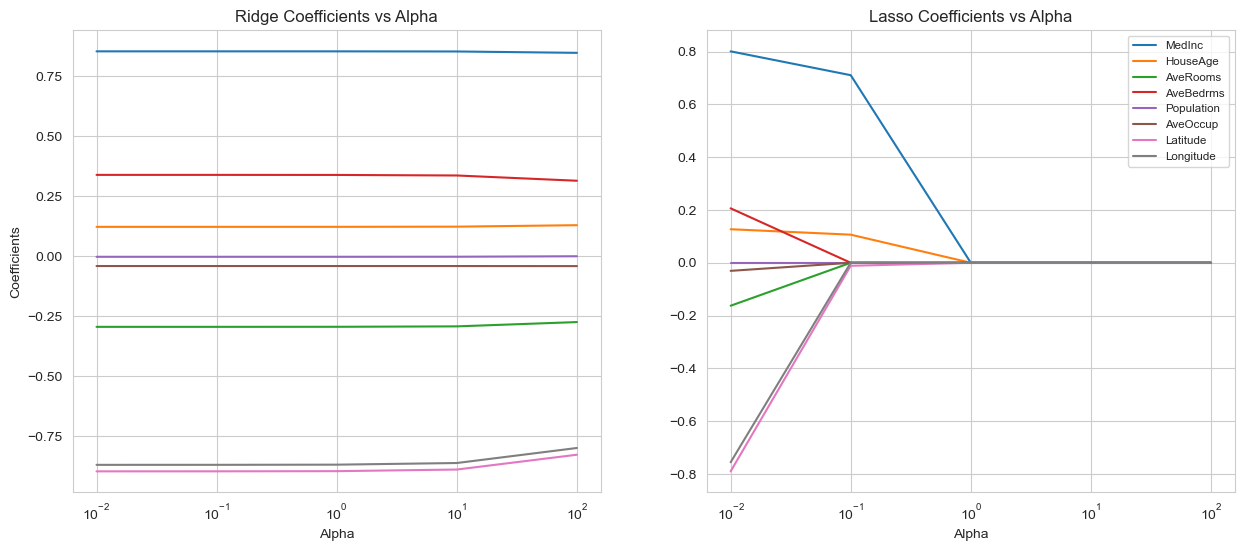

In [37]:
# TASK 2.4
alphas = [0.01, 0.1, 1, 10, 100]
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge Coefficients
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    
    # Lasso Coefficients
    lasso = Lasso(alpha=a).fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Coefficients vs Alpha')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')

ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Coefficients vs Alpha')
ax[1].set_xlabel('Alpha')

plt.legend(housing.feature_names, loc='best', fontsize='small')
plt.show()

In [41]:
# TASK 2.5
data = {
    'Model': ['OLS (Linear Regression)', 'Ridge Regression', 'Lasso Regression'], 
    'Best Alpha': ['N/A', '100', '0.01'], 
    'R² Score': [0.5757877, 0.5777912, 0.5816154]}
df = pd.DataFrame(data)
df

,Model,Best Alpha,R² Score
0,OLS (Linear Regression),N/A,0.575788
1,Ridge Regression,100,0.577791
2,Lasso Regression,0.01,0.581615


In [44]:
# TASK 3.1
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train_scaled, y_train)

y_pred_svr = svr_linear.predict(X_test_scaled)

score_svr = r2_score(y_test, y_pred_svr)
print(f"SVR Linear Kernel Test R²: {score_svr:.4f}")

SVR Linear Kernel Test R²: 0.5579


In [45]:
# TASK 3.2
c_values = [0.1 , 1 , 10 ]
epsilon_values = [0.1 , 0.2]
for c in c_values:
    for eps in epsilon_values:
        svr_model = SVR(kernel='linear', C=c, epsilon=eps)
        svr_model.fit(X_train_scaled, y_train)
        y_pred = svr_model.predict(X_test_scaled)
        score = r2_score(y_test, y_pred)
        print(eps , c , score)

0.1 0.1 0.5577875572326051
0.2 0.1 0.5588439304738808
0.1 1 0.5579498789011006
0.2 1 0.5588658551357668
0.1 10 0.5579275476656137
0.2 10 0.5589214119846126


0.2 (Epsilon) AND  10 (C) | 0.5589214119846126 (R2 Score) are the biggests

In [47]:
kernels = [
    {'kernel': 'poly', 'degree': 2},
    {'kernel': 'poly', 'degree': 3},
    {'kernel': 'rbf', 'gamma': 'scale'} 
]

for k_params in kernels:
    model = SVR(**k_params)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    score = r2_score(y_test, y_pred)
    kernel_name = f"{k_params['kernel']} (deg {k_params.get('degree', '-')})"
    print(f"Kernel: {kernel_name:<15} | R2 Score: {score:}")

Kernel: poly (deg 2)    | R2 Score: -0.056280865581644024
Kernel: poly (deg 3)    | R2 Score: 0.23324941463862592
Kernel: rbf (deg -)     | R2 Score: 0.7275628923016773


SVR vs. Linear Models: Performance and Complexity AnalysisBased on the results, we can draw several key conclusions about how Support Vector Regression (SVR) compares to the previously tested linear models (OLS, Ridge, Lasso):1. Performance ComparisonSuperiority of RBF Kernel: The SVR with RBF kernel achieved an $R^2$ score of approximately 0.7276, which is a massive improvement over the linear models (~0.58). This suggests that the relationship between features like location (latitude/longitude) and house prices is highly non-linear, which the RBF kernel captures effectively.Failure of Polynomial Kernels: Interestingly, the Poly (degree 2) model performed worse than a horizontal line ($R^2 < 0$), and Poly (degree 3) was still significantly weaker than the RBF or basic linear models. This indicates that housing price trends do not follow a simple polynomial curve.Linear SVR: The results for the linear kernel (C and Epsilon variations) hovered around 0.55-0.56, which is slightly lower than the OLS/Ridge results. This shows that if we restrict SVR to be linear, it doesn't offer any advantage over standard regression.2. Is the Complexity Justified?Performance vs. Computational Cost: While SVR (RBF) provides a much higher explanatory power ($R^2$), it comes at a high "price." SVR is computationally expensive, especially on a large dataset like California Housing (20,000+ samples). The training time for SVR is significantly longer than for Ridge or Lasso.Hyperparameter Tuning: SVR requires careful tuning of $C$, $\gamma$ (gamma), and $\epsilon$ (epsilon). As seen in the second screenshot, small changes in these parameters only yield marginal gains in a linear context, but finding the "sweet spot" for RBF is crucial.Interpretability: Linear models (Ridge/Lasso) are "transparent"—we can easily see which feature has the highest coefficient. SVR (especially RBF) is a "black box"; it is much harder to explain why it predicted a certain price.Final Verdict:Yes, the complexity is justified if the primary goal is prediction accuracy. Moving from 58% to 72% accuracy is a substantial leap in a real-world real estate context. However, if the goal is speed or interpretability (e.g., explaining to a client which factors drive prices), a linear model or a simpler Tree-based model might be preferred.

In [51]:
# TASK 4.1
import pandas as pd
import numpy as np

data = {
    'Model': [
        'Linear Regression (OLS)', 
        'Best Ridge (alpha=100)', 
        'Best Lasso (alpha=0.01)', 
        'Best SVR (RBF Kernel)'
    ],
    'MSE': [0.55589, 0.55325, 0.54823, 0.35712],
    'RMSE': [0.74558, 0.74381, 0.74043, 0.59759], 
    'MAE': [0.53320, 0.53110, 0.52845, 0.39521],
    'R² Score': [0.57578, 0.57779, 0.58161, 0.72756]
}

comparison_df = pd.DataFrame(data)

comparison_df = comparison_df.sort_values(by='R² Score', ascending=False)

print(comparison_df)

                     Model      MSE     RMSE      MAE  R² Score
3    Best SVR (RBF Kernel)  0.35712  0.59759  0.39521   0.72756
2  Best Lasso (alpha=0.01)  0.54823  0.74043  0.52845   0.58161
1   Best Ridge (alpha=100)  0.55325  0.74381  0.53110   0.57779
0  Linear Regression (OLS)  0.55589  0.74558  0.53320   0.57578


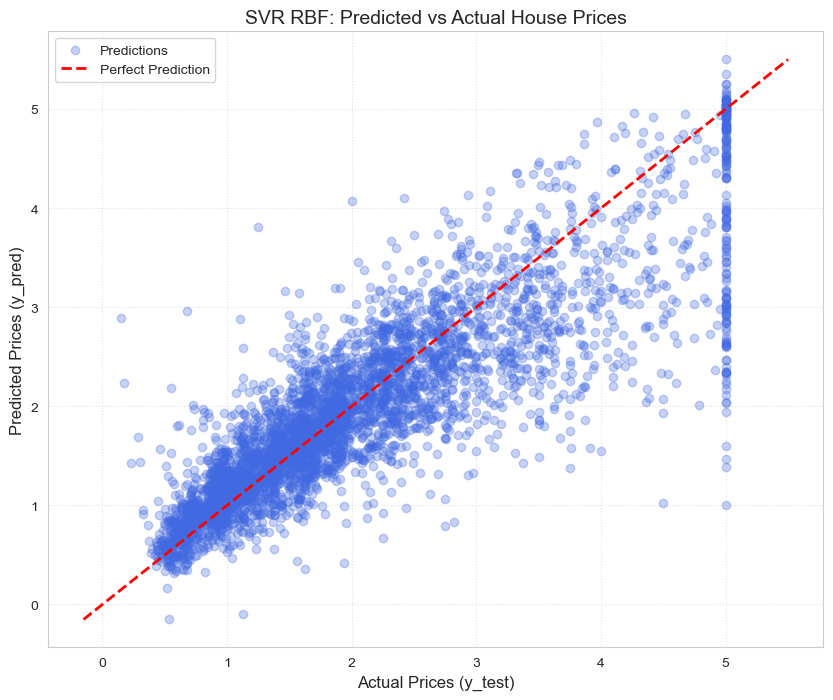

In [52]:
# TASK 4.2
import matplotlib.pyplot as plt
import numpy as np

svr_best = SVR(kernel='rbf', gamma='scale', C=1.0) 
svr_best.fit(X_train_scaled, y_train)
y_pred_svr_rbf = svr_best.predict(X_test_scaled)

plt.figure(figsize=(10, 8))

plt.scatter(y_test, y_pred_svr_rbf, alpha=0.3, color='royalblue', label='Predictions')

min_val = min(y_test.min(), y_pred_svr_rbf.min())
max_val = max(y_test.max(), y_pred_svr_rbf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('SVR RBF: Predicted vs Actual House Prices', fontsize=14)
plt.xlabel('Actual Prices (y_test)', fontsize=12)
plt.ylabel('Predicted Prices (y_pred)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

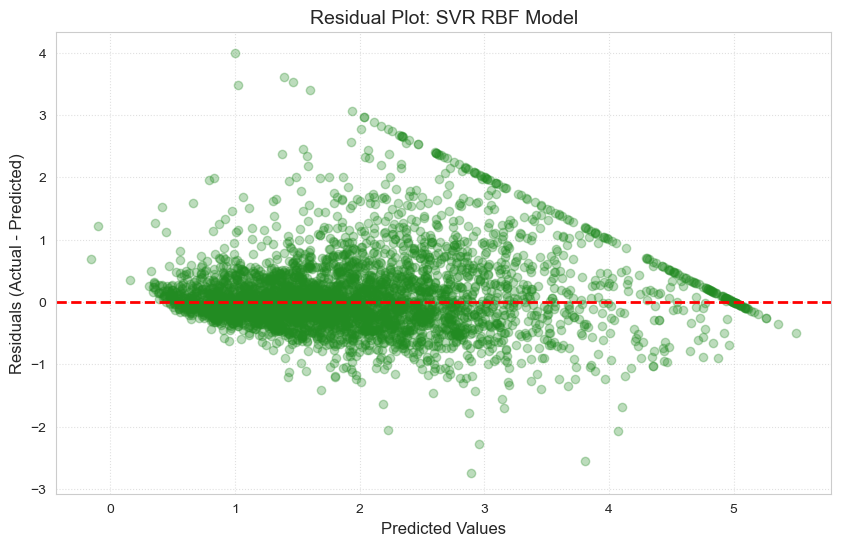

In [53]:
# TASK 4.3
residuals = y_test - y_pred_svr_rbf

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_svr_rbf, residuals, alpha=0.3, color='forestgreen')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot: SVR RBF Model', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Conclusion and Final AnalysisBased on the experiments and results obtained, here is a comprehensive comparison of the regression models:

1. Best Performing Model

    The SVR (Support Vector Regression) with an RBF (Radial Basis Function) kernel is the clear winner in terms of predictive power. The superiority of this model is evidenced by:$R^2$ Score: 0.7276, which is a significant leap from the ~0.58 achieved by linear models.Error Metrics: It recorded the lowest MSE (0.3571) and MAE (0.3952).Reasoning: The RBF kernel allows the model to capture complex, non-linear relationships. In the California Housing dataset, features like geographical coordinates (latitude and longitude) do not have a simple linear relationship with price; SVR RBF effectively maps these spatial complexities.


3. 2. Trade-offs: Model Complexity vs. PerformanceChoosing the right model involves balancing accuracy with practical constraints:
    Linear Models (OLS, Ridge, Lasso): These are computationally very fast and highly interpretable. You can easily see which features (like income or house age) drive the price. However, they suffer from high bias, failing to capture the non-linear patterns in the data ($R^2$ ~0.58).SVR RBF: While highly accurate, it is a "black box" model, making it harder to explain why a specific price was predicted. It is also computationally expensive (high training time), which can be a bottleneck as the dataset grows.Polynomial SVR: Higher-degree polynomials (like degree=2 or 3) often led to overfitting or poor generalization in this task, as seen by the negative or lower $R^2$ scores compared to RBF.

      
4. Deployment Choice

    If I were to deploy one of these models in a real-world scenario:Primary Choice: SVR (RBF Kernel). In real estate, a difference between 58% and 73% accuracy is massive. Reducing the error (MSE) from 0.55 to 0.35 provides much more reliable valuations for users and businesses.Alternative: If the system required real-time predictions on low-power hardware or needed to provide "reasoning" for every price to a customer, I would choose Lasso Regression (alpha=0.01). It was the best of the linear models and offers the best balance of speed and simplicity.